In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
#import necessary libraries for modelling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#load all columns
pd.set_option('display.max_columns', None)

In [7]:
#load dataset
df = pd.read_csv('/content/drive/MyDrive/cleaned_superstore.csv')
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9977 entries, 0 to 9976
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9977 non-null   object 
 1   Segment       9977 non-null   object 
 2   Country       9977 non-null   object 
 3   City          9977 non-null   object 
 4   State         9977 non-null   object 
 5   Postal Code   9977 non-null   int64  
 6   Region        9977 non-null   object 
 7   Category      9977 non-null   object 
 8   Sub-Category  9977 non-null   object 
 9   Sales         9977 non-null   float64
 10  Quantity      9977 non-null   int64  
 11  Discount      9977 non-null   float64
 12  Profit        9977 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1013.4+ KB


In [9]:
# converting postal code to obj
df['Postal Code'] = df['Postal Code'].astype(str)
df.dtypes

,0
Ship Mode,object
Segment,object
Country,object
City,object
State,object
Postal Code,object
Region,object
Category,object
Sub-Category,object
Sales,float64


# **DEFINING ML PROBLEM**
DETECTING IF A TRANSACTION WILL BE PROFITABLE OR UNPROFITABLE EVEN BEFORE IT HAPPENS.
Can we predict whether a transaction will be profitable even before making it?

In [10]:
#creating target variable
df['Profit Status'] = df['Profit'].apply(
    lambda x: 'profitable' if x > 0 else 'unprofitable'
)

In [11]:
df[['Profit', 'Profit Status']].head()

,Profit,Profit Status
0,41.9136,profitable
1,219.5820,profitable
2,6.8714,profitable
3,-383.0310,unprofitable
4,2.5164,profitable


In [12]:
df['Profit Status'].value_counts()

,count
Profit Status,
profitable,8043
unprofitable,1934


<function matplotlib.pyplot.show(close=None, block=None)>

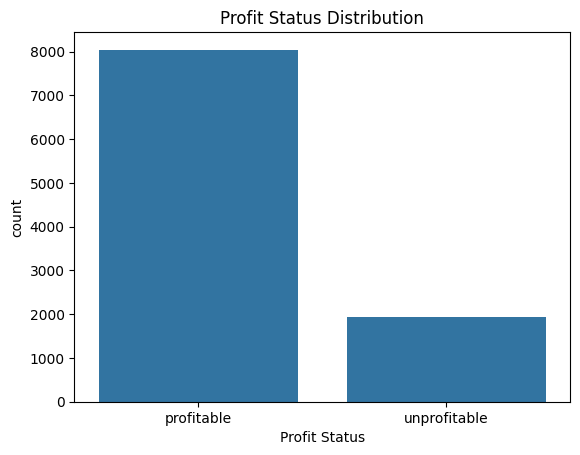

In [13]:
#visualise
sns.countplot(x='Profit Status',data=df)
plt.title('Profit Status Distribution')
plt.show

In [14]:
#define X and Y features
X = df.drop(columns=['Profit', 'Profit Status'])

y = df['Profit Status']

In [15]:
X.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20


In [16]:
y.head()

,Profit Status
0,profitable
1,profitable
2,profitable
3,unprofitable
4,profitable


In [17]:
#encoding categorical variables to numerical readable data
X_encoded = pd.get_dummies(X, drop_first=True)

In [18]:
X_encoded.head()

,Sales,Quantity,Discount,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Corporate,Segment_Home Office,City_Abilene,City_Akron,City_Albuquerque,City_Alexandria,City_Allen,City_Allentown,City_Altoona,City_Amarillo,City_Anaheim,City_Andover,City_Ann Arbor,City_Antioch,City_Apopka,City_Apple Valley,City_Appleton,City_Arlington,City_Arlington Heights,City_Arvada,City_Asheville,City_Athens,City_Atlanta,City_Atlantic City,City_Auburn,City_Aurora,City_Austin,City_Avondale,City_Bakersfield,City_Baltimore,City_Bangor,City_Bartlett,City_Bayonne,City_Baytown,City_Beaumont,City_Bedford,City_Belleville,City_Bellevue,City_Bellingham,City_Bethlehem,City_Beverly,City_Billings,City_Bloomington,City_Boca Raton,City_Boise,City_Bolingbrook,City_Bossier City,City_Bowling Green,City_Boynton Beach,City_Bozeman,City_Brentwood,City_Bridgeton,City_Bristol,City_Broken Arrow,City_Broomfield,City_Brownsville,City_Bryan,City_Buffalo,City_Buffalo Grove,City_Bullhead City,City_Burbank,City_Burlington,City_Caldwell,City_Camarillo,City_Cambridge,City_Canton,City_Carlsbad,City_Carol Stream,City_Carrollton,City_Cary,City_Cedar Hill,City_Cedar Rapids,City_Champaign,City_Chandler,City_Chapel Hill,City_Charlotte,City_Charlottesville,City_Chattanooga,City_Chesapeake,City_Chester,City_Cheyenne,City_Chicago,City_Chico,City_Chula Vista,City_Cincinnati,City_Citrus Heights,City_Clarksville,City_Cleveland,City_Clifton,City_Clinton,City_Clovis,City_Coachella,City_College Station,City_Colorado Springs,City_Columbia,City_Columbus,City_Commerce City,City_Concord,City_Conroe,City_Conway,City_Coon Rapids,City_Coppell,City_Coral Gables,City_Coral Springs,City_Corpus Christi,City_Costa Mesa,City_Cottage Grove,City_Covington,City_Cranston,City_Cuyahoga Falls,City_Dallas,City_Danbury,City_Danville,City_Davis,City_Daytona Beach,City_Dearborn,City_Dearborn Heights,City_Decatur,City_Deer Park,City_Delray Beach,City_Deltona,City_Denver,City_Des Moines,City_Des Plaines,City_Detroit,City_Dover,City_Draper,City_Dublin,City_Dubuque,City_Durham,City_Eagan,City_East Orange,City_East Point,City_Eau Claire,City_Edinburg,City_Edmond,City_Edmonds,City_El Cajon,City_El Paso,City_Elkhart,City_Elmhurst,City_Elyria,City_Encinitas,City_Englewood,City_Escondido,City_Eugene,City_Evanston,City_Everett,City_Fairfield,City_Fargo,City_Farmington,City_Fayetteville,City_Florence,City_Fort Collins,City_Fort Lauderdale,City_Fort Worth,City_Frankfort,City_Franklin,City_Freeport,City_Fremont,City_Fresno,City_Frisco,City_Gaithersburg,City_Garden City,City_Garland,City_Gastonia,City_Georgetown,City_Gilbert,City_Gladstone,City_Glendale,City_Glenview,City_Goldsboro,City_Grand Island,City_Grand Prairie,City_Grand Rapids,City_Grapevine,City_Great Falls,City_Greeley,City_Green Bay,City_Greensboro,City_Greenville,City_Greenwood,City_Gresham,City_Grove City,City_Gulfport,City_Hackensack,City_Hagerstown,City_Haltom City,City_Hamilton,City_Hampton,City_Harlingen,City_Harrisonburg,City_Hattiesburg,City_Helena,City_Hempstead,City_Henderson,City_Hendersonville,City_Hesperia,City_Hialeah,City_Hickory,City_Highland Park,City_Hillsboro,City_Holland,City_Hollywood,City_Holyoke,City_Homestead,City_Hoover,City_Hot Springs,City_Houston,City_Huntington Beach,City_Huntsville,City_Independence,City_Indianapolis,City_Inglewood,City_Iowa City,City_Irving,City_Jackson,City_Jacksonville,City_Jamestown,City_Jefferson City,City_Johnson City,City_Jonesboro,City_Jupiter,City_Keller,City_Kenner,City_Kenosha,City_Kent,City_Kirkwood,City_Kissimmee,City_Knoxville,City_La Crosse,City_La Mesa,City_La Porte,City_La Quinta,City_Lafayette,City_Laguna Niguel,City_Lake Charles,City_Lake Elsinore,City_Lake Forest,City_Lakeland,City_Lakeville,City_Lakewood,City_Lancaster,City_Lansing,City_Laredo,City_Las Cruces,City_Las Vegas,City_Laurel,City_Lawrence,City_Lawton,City_Layton,City_League City,City_Lebanon,City_Lehi,City_Leominster,City_Lewiston,City_Lincoln Park,City_Linden,City_Lindenhurst,City_Little Rock,City_Littleton,City_Lod

In [19]:
X_encoded.shape

(9977, 1237)

In [20]:
# Spliting the datasets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y, test_size=0.2,
    random_state=42
)


# **MODEL TRAINING**

### *LOGISTICS REGRESSION*

In [21]:
#import logistic regression library
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [22]:
# Initialise and train model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Make predictions
lr_predictions = lr_model.predict(X_test)

#Accuracy
print(f'Model Accuracy: {lr_model.score(X_test, y_test):.2f}')

#classification report
print(classification_report(y_test, lr_predictions))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model Accuracy: 0.94
              precision    recall  f1-score   support

  profitable       0.95      0.98      0.96      1624
unprofitable       0.90      0.77      0.83       372

    accuracy                           0.94      1996
   macro avg       0.93      0.87      0.90      1996
weighted avg       0.94      0.94      0.94      1996



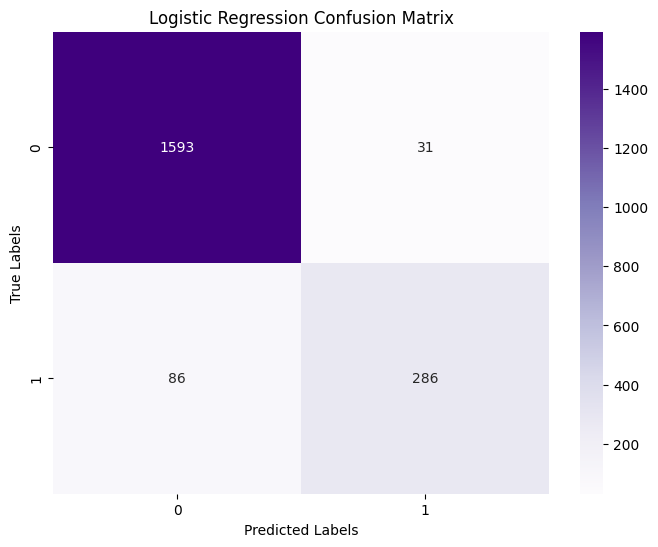

In [23]:
# confusion matrix
con_matrix= confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(con_matrix,
            annot=True,
            fmt='d',
            cmap='Purples')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

### *RANDOM FOREST*

In [24]:
# Import Random Forest model library
from sklearn.ensemble import RandomForestClassifier

#Initialize model
rf_model = RandomForestClassifier(random_state=42)

#Train model
rf_model.fit(X_train, y_train)

#Make predictions
rf_predictions = rf_model.predict(X_test)

#Accuracy
print(f'Model Accuracy: {rf_model.score(X_test, y_test):.2f}')

#classification report
print(classification_report(y_test, rf_predictions))
#

Model Accuracy: 0.94
              precision    recall  f1-score   support

  profitable       0.95      0.99      0.97      1624
unprofitable       0.93      0.76      0.84       372

    accuracy                           0.94      1996
   macro avg       0.94      0.87      0.90      1996
weighted avg       0.94      0.94      0.94      1996



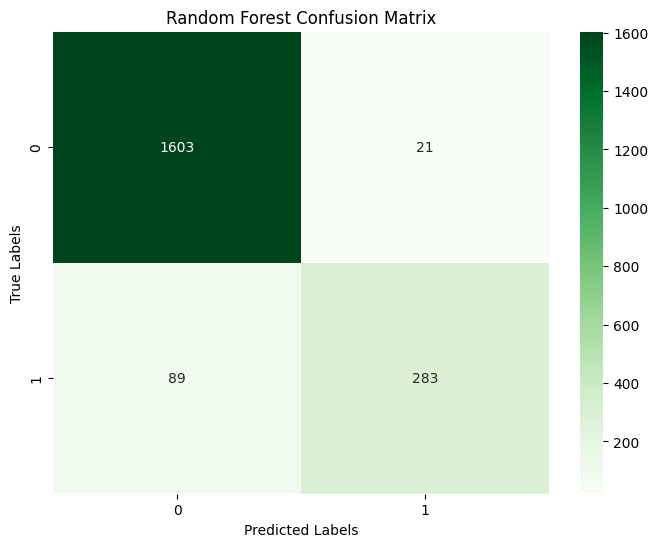

In [25]:
# Confusion matrix
con_matrix= confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(con_matrix,
            annot=True,
            fmt='d',
            cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Both Logistic Regression and Random Forest achieved similarly strong classification performance, with overall accuracy around 94%. The comparable results suggest that the dataset contains stable and learnable profitability patterns. While Random Forest slightly improved precision for detecting unprofitable transactions, both models demonstrated strong capability in identifying business profitability outcomes.

### *DECISION TREE*

In [26]:
# Import decision tree library
from sklearn.tree import DecisionTreeClassifier

# Initialize model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Make predictions
dt_predictions = dt_model.predict(X_test)

# Accuracy
print(f'Model Accuracy: {dt_model.score(X_test, y_test):.2f}')

# classification report
print(classification_report(y_test, dt_predictions))


Model Accuracy: 0.94
              precision    recall  f1-score   support

  profitable       0.96      0.97      0.96      1624
unprofitable       0.86      0.81      0.83       372

    accuracy                           0.94      1996
   macro avg       0.91      0.89      0.90      1996
weighted avg       0.94      0.94      0.94      1996



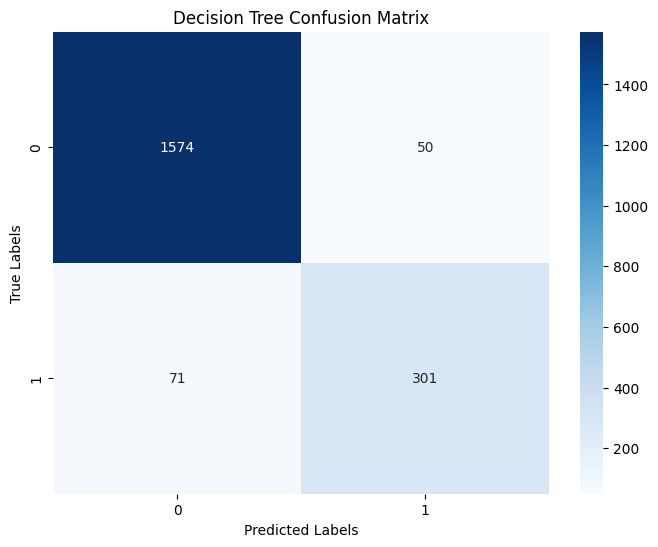

In [27]:
#confusion matrix
con_matrix= confusion_matrix(y_test, dt_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(con_matrix,
            annot=True,
            fmt='d',
            cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

### *GRADIENT BOOST*

In [28]:
# Import gradient boost library
from sklearn.ensemble import GradientBoostingClassifier

# Initialize model
gb_model = GradientBoostingClassifier(random_state=42)

# Train model
gb_model.fit(X_train, y_train)

# Make predictions
gb_predictions = gb_model.predict(X_test)

# Accuracy
print(f'Model Accuracy: {gb_model.score(X_test, y_test):.2f}')

# classification report
print(classification_report(y_test, gb_predictions))



Model Accuracy: 0.95
              precision    recall  f1-score   support

  profitable       0.95      0.99      0.97      1624
unprofitable       0.96      0.75      0.84       372

    accuracy                           0.95      1996
   macro avg       0.95      0.87      0.90      1996
weighted avg       0.95      0.95      0.94      1996



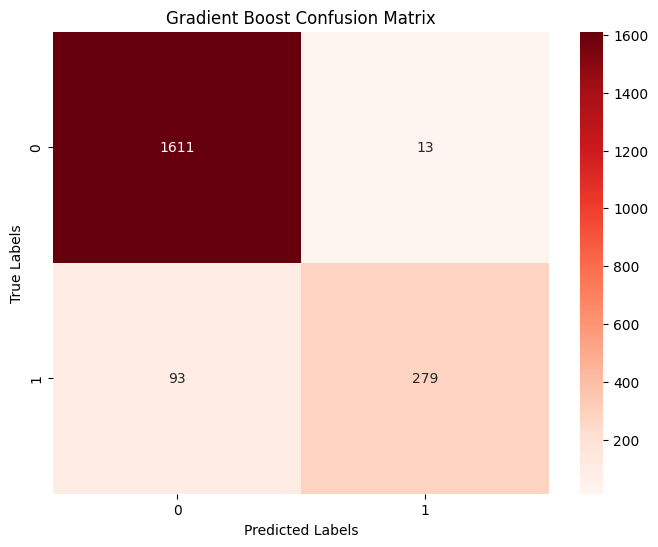

In [29]:
#confusion matrix
con_matrix= confusion_matrix(y_test, gb_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(con_matrix,
            annot=True,
            fmt='d',
            cmap='Reds')
plt.title('Gradient Boost Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Although Gradient Boosting achieved the highest overall accuracy, the Decision Tree model was selected as the preferred model because it achieved the highest recall for unprofitable transactions. Since the primary business objective is to identify and reduce loss-making transactions, maximizing the detection of unprofitable cases is more valuable than marginal improvements in overall accuracy. Additionally, the interpretability of Decision Trees makes the model more suitable for business decision-making and explainability.

## *FEATURE IMPORTANCE*

In [30]:
# Feature importance for decision tree
dt_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_model.feature_importances_
})

# Sort features by importance
dt_importance = dt_importance.sort_values(by='Importance', ascending=False)

dt_importance.head()


,Feature,Importance
2,Discount,0.662478
0,Sales,0.090594
1234,Sub-Category_Storage,0.033234
1,Quantity,0.025383
1219,Category_Office Supplies,0.019933


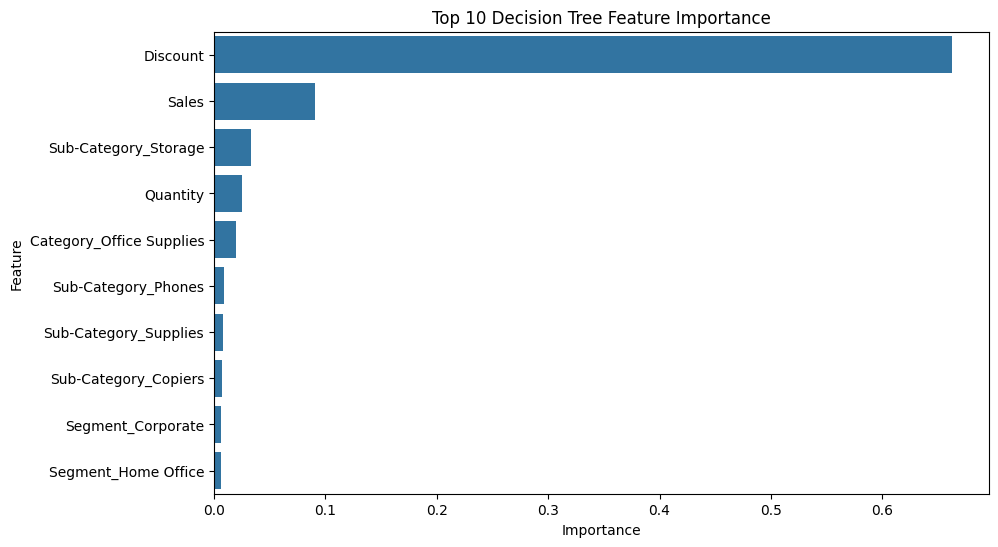

In [31]:
# visualize
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=dt_importance.head(10))
plt.title('Top 10 Decision Tree Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [32]:
# random forest feature importance
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort features by importance
rf_importance = rf_importance.sort_values(by='Importance', ascending=False)

rf_importance.head()

,Feature,Importance
2,Discount,0.288833
0,Sales,0.084600
1,Quantity,0.044835
1223,Sub-Category_Binders,0.031305
578,State_Texas,0.026971


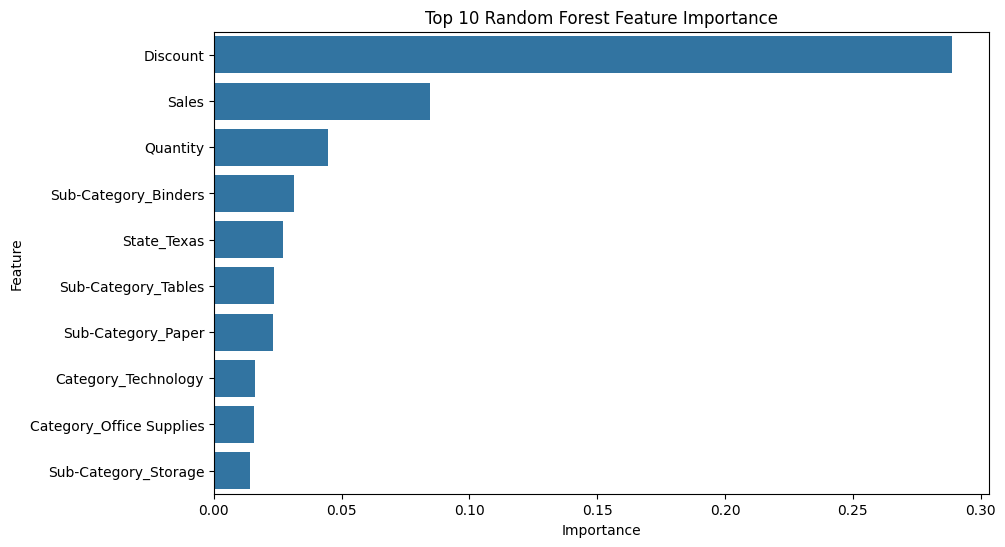

In [33]:
# visualize
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importance.head(10))
plt.title('Top 10 Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [34]:
# feature importance for gradient boost
gb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb_model.feature_importances_
})
# sort by importance
gb_importance = gb_importance.sort_values(by='Importance', ascending=False)

gb_importance.head()

,Feature,Importance
2,Discount,0.869666
1234,Sub-Category_Storage,0.047165
0,Sales,0.016571
1219,Category_Office Supplies,0.011026
1226,Sub-Category_Copiers,0.008819


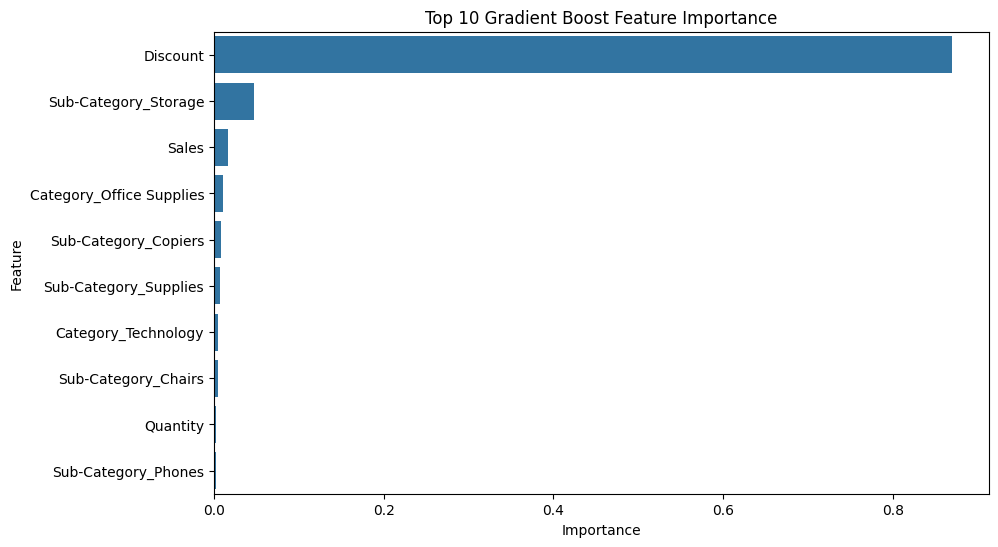

In [35]:
# visualize
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=gb_importance.head(10))
plt.title('Top 10 Gradient Boost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [36]:
# coefficient for logistic regression
lr_coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
})
lr_coefficients['Absolute_Coefficient'] = abs(lr_coefficients['Coefficient'])

lr_coefficients = lr_coefficients.sort_values(by='Absolute_Coefficient', ascending=False)

lr_coefficients.head()
#

,Feature,Coefficient,Absolute_Coefficient
2,Discount,13.563542,13.563542
1234,Sub-Category_Storage,2.969068,2.969068
1226,Sub-Category_Copiers,-2.773524,2.773524
1219,Category_Office Supplies,-2.703830,2.703830
1232,Sub-Category_Paper,-2.603379,2.603379


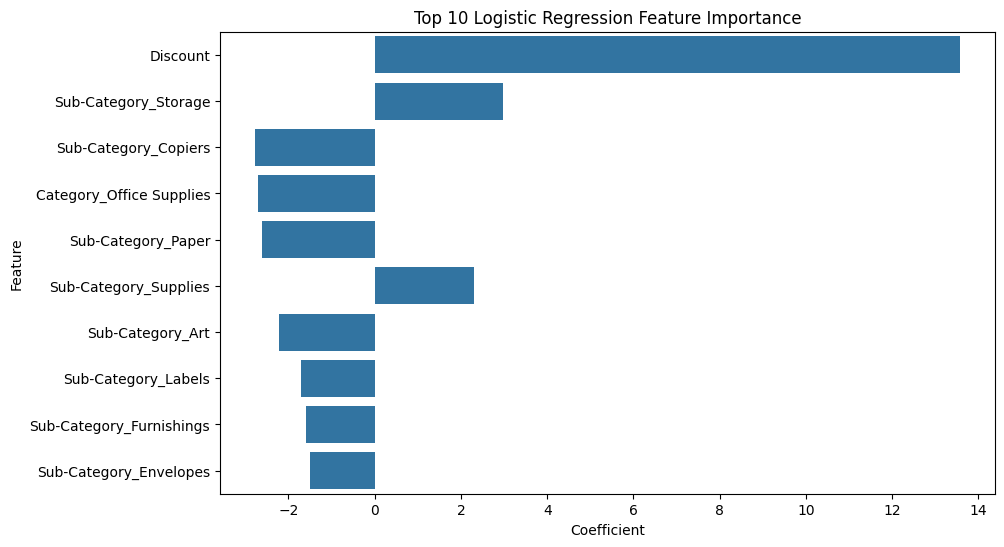

In [37]:
# visualize
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=lr_coefficients.head(10))
plt.title('Top 10 Logistic Regression Feature Importance')  #
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.show()

# *FINAL ML INSIGHT*
Feature importance analysis across multiple machine learning models consistently identified Discount as the strongest predictor of transaction profitability. This validates earlier exploratory analysis findings showing that aggressive discounting significantly contributes to unprofitable transactions, particularly within Furniture subcategories such as Tables and Furnishings. Additional influential features included Sales, Quantity, and specific product subcategories, indicating that both pricing strategy and product type strongly affect profitability outcomes.

In [38]:
# Saving the best Model
import joblib

joblib.dump(dt_model, 'decision_tree_model.pkl')

['decision_tree_model.pkl']

In [39]:
# Save feature column
joblib.dump(X_train.columns, 'feature_columns.pkl')

['feature_columns.pkl']